Input Shape for Hybrid Model: (73651, 11, 1)

--- Training CNN Stage ---
Epoch 1/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1538 - mae: 0.2777 - val_loss: 0.1314 - val_mae: 0.2591
Epoch 2/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1336 - mae: 0.2588 - val_loss: 0.1244 - val_mae: 0.2482
Epoch 3/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1261 - mae: 0.2505 - val_loss: 0.1157 - val_mae: 0.2391
Epoch 4/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1203 - mae: 0.2444 - val_loss: 0.1211 - val_mae: 0.2516
Epoch 5/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1150 - mae: 0.2391 - val_loss: 0.1158 - val_mae: 0.2469
Epoch 6/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1118 - mae: 0.2363 - val_loss: 0.1083 - val_mae: 0.2396
Epoch 7/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1082 - mae: 0.2326 - val_loss: 0.1074 - val_mae: 0.2383
Epoch 8/40
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1056 - mae: 0.2304 - va

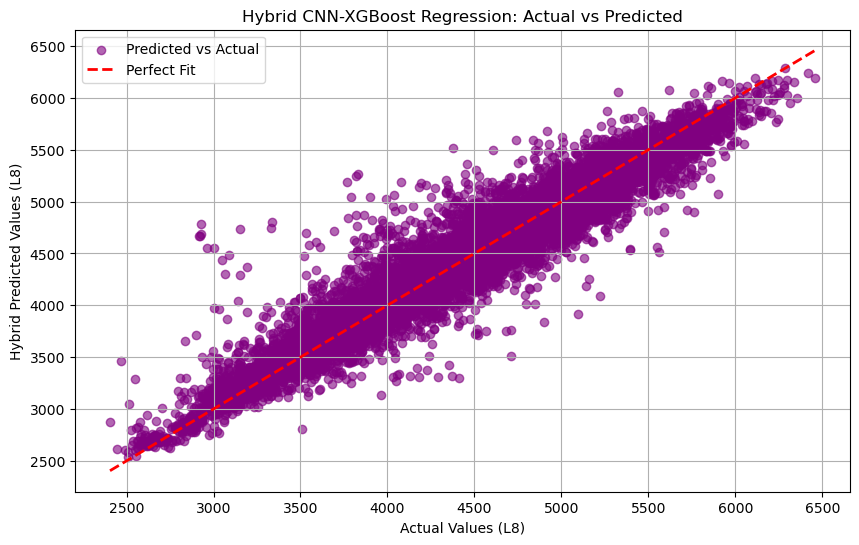

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
# Added Input to imports
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load the dataset
try:
    df = pd.read_excel("Feature_engineering_DS.xlsx")
except FileNotFoundError:
    print("Error: File 'Feature_engineering_DS.xlsx' not found. Please ensure it is in the directory.")
    exit()

# Define features (X) and target (y)
X = df.drop(["L8", "date"], axis=1).values
y = df["L8"].values.reshape(-1, 1)

# Split Data: 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scale Data
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
y_train_s = y_scaler.fit_transform(y_train)

X_val_s = x_scaler.transform(X_val)
y_val_s = y_scaler.transform(y_val)

X_test_s = x_scaler.transform(X_test)
y_test_s = y_scaler.transform(y_test)

# Reshape for CNN [samples, time_steps, features]
X_train_cnn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_val_cnn = X_val_s.reshape(X_val_s.shape[0], X_val_s.shape[1], 1)
X_test_cnn = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

print(f"Input Shape for Hybrid Model: {X_train_cnn.shape}")

# ==========================================
# 2. TRAIN CNN (Feature Extractor Stage)
# ==========================================
print("\n--- Training CNN Stage ---")

# [FIX] Use Functional API instead of Sequential to ensure .input is accessible
inputs = Input(shape=(X_train_cnn.shape[1], 1))
x = Conv1D(filters=64, kernel_size=2, activation='relu')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(filters=32, kernel_size=2, activation='relu')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
# Named layer for feature extraction
features = Dense(32, activation='relu', name='feature_layer')(x)
outputs = Dense(1, activation='linear')(features)

cnn_model = Model(inputs=inputs, outputs=outputs)

optimizer = Adam(learning_rate=0.001)
cnn_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_model.fit(
    X_train_cnn, y_train_s,
    validation_data=(X_val_cnn, y_val_s),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 3. HYBRIDIZATION (Feature Extraction)
# ==========================================
print("\n--- Extracting Features from CNN for XGBoost ---")

# Create the feature extractor model
# With Functional API, cnn_model.input is explicitly defined and safe to use
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer('feature_layer').output)

# Extract features
X_train_features = feature_extractor.predict(X_train_cnn)
X_val_features = feature_extractor.predict(X_val_cnn)
X_test_features = feature_extractor.predict(X_test_cnn)

print(f"New Feature Shape for XGBoost: {X_train_features.shape}")

# ==========================================
# 4. TRAIN XGBOOST (Regressor Stage)
# ==========================================
print("\n--- Training XGBoost on CNN Features ---")

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

xgb_model.fit(
    X_train_features, 
    y_train_s.ravel(), 
    eval_set=[(X_val_features, y_val_s.ravel())], 
    verbose=False
)

# ==========================================
# 5. EVALUATION
# ==========================================
pred_s = xgb_model.predict(X_test_features).reshape(-1, 1)

pred_real = y_scaler.inverse_transform(pred_s)
y_test_real = y_scaler.inverse_transform(y_test_s)

rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
mae = mean_absolute_error(y_test_real, pred_real)
mse = mean_squared_error(y_test_real, pred_real)
r2 = r2_score(y_test_real, pred_real)

print("\n--- Hybrid CNN-XGBoost Model Results ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"R2  : {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, pred_real, alpha=0.6, color='purple', label='Predicted vs Actual')
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Values (L8)")
plt.ylabel("Hybrid Predicted Values (L8)")
plt.title("Hybrid CNN-XGBoost Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

Input Shape for Hybrid Model: (73651, 11, 1)

--- Training CNN Stage ---
Epoch 1/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1532 - mae: 0.2781 - val_loss: 0.1282 - val_mae: 0.2524
Epoch 2/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1327 - mae: 0.2578 - val_loss: 0.1264 - val_mae: 0.2538
Epoch 3/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1254 - mae: 0.2502 - val_loss: 0.1327 - val_mae: 0.2718
Epoch 4/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1185 - mae: 0.2435 - val_loss: 0.1228 - val_mae: 0.2609
Epoch 5/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1143 - mae: 0.2396 - val_loss: 0.1288 - val_mae: 0.2692
Epoch 6/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1102 - mae: 0.2354 - val_loss: 0.1231 - val_mae: 0.2611
Epoch 7/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1074 - mae: 0.2321 - val_loss: 0.1213 - val_mae: 0.2631
Epoch 8/100
2302/2302 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1047 - mae: 0.2

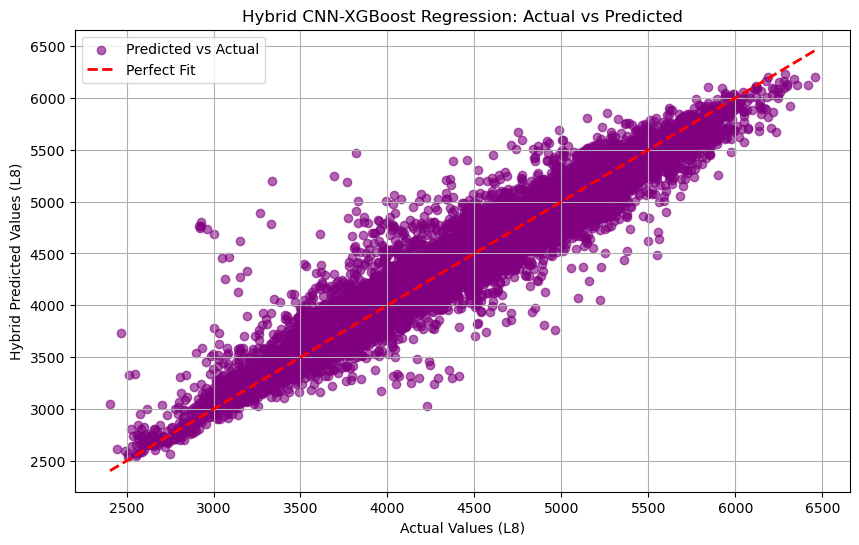

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
# Added Input to imports
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load the dataset
try:
    df = pd.read_excel("Feature_engineering_DS.xlsx")
except FileNotFoundError:
    print("Error: File 'Feature_engineering_DS.xlsx' not found. Please ensure it is in the directory.")
    exit()

# Define features (X) and target (y)
X = df.drop(["L8", "date"], axis=1).values
y = df["L8"].values.reshape(-1, 1)

# Split Data: 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Scale Data
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
y_train_s = y_scaler.fit_transform(y_train)

X_val_s = x_scaler.transform(X_val)
y_val_s = y_scaler.transform(y_val)

X_test_s = x_scaler.transform(X_test)
y_test_s = y_scaler.transform(y_test)

# Reshape for CNN [samples, time_steps, features]
X_train_cnn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_val_cnn = X_val_s.reshape(X_val_s.shape[0], X_val_s.shape[1], 1)
X_test_cnn = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

print(f"Input Shape for Hybrid Model: {X_train_cnn.shape}")

# ==========================================
# 2. TRAIN CNN (Feature Extractor Stage)
# ==========================================
print("\n--- Training CNN Stage ---")

# [FIX] Use Functional API instead of Sequential to ensure .input is accessible
inputs = Input(shape=(X_train_cnn.shape[1], 1))
x = Conv1D(filters=64, kernel_size=2, activation='relu')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(filters=32, kernel_size=2, activation='relu')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
# Named layer for feature extraction
features = Dense(32, activation='relu', name='feature_layer')(x)
outputs = Dense(1, activation='linear')(features)

cnn_model = Model(inputs=inputs, outputs=outputs)

optimizer = Adam(learning_rate=0.001)
cnn_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_model.fit(
    X_train_cnn, y_train_s,
    validation_data=(X_val_cnn, y_val_s),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 3. HYBRIDIZATION (Feature Extraction)
# ==========================================
print("\n--- Extracting Features from CNN for XGBoost ---")

# Create the feature extractor model
# With Functional API, cnn_model.input is explicitly defined and safe to use
feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.get_layer('feature_layer').output)

# Extract features
X_train_features = feature_extractor.predict(X_train_cnn)
X_val_features = feature_extractor.predict(X_val_cnn)
X_test_features = feature_extractor.predict(X_test_cnn)

print(f"New Feature Shape for XGBoost: {X_train_features.shape}")

# ==========================================
# 4. TRAIN XGBOOST (Regressor Stage)
# ==========================================
print("\n--- Training XGBoost on CNN Features ---")

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

xgb_model.fit(
    X_train_features, 
    y_train_s.ravel(), 
    eval_set=[(X_val_features, y_val_s.ravel())], 
    verbose=False
)

# ==========================================
# 5. EVALUATION
# ==========================================
pred_s = xgb_model.predict(X_test_features).reshape(-1, 1)

pred_real = y_scaler.inverse_transform(pred_s)
y_test_real = y_scaler.inverse_transform(y_test_s)

rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
mae = mean_absolute_error(y_test_real, pred_real)
mse = mean_squared_error(y_test_real, pred_real)
r2 = r2_score(y_test_real, pred_real)

print("\n--- Hybrid CNN-XGBoost Model Results ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"R2  : {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, pred_real, alpha=0.6, color='purple', label='Predicted vs Actual')
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Values (L8)")
plt.ylabel("Hybrid Predicted Values (L8)")
plt.title("Hybrid CNN-XGBoost Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()